#1.  Purchase Order Quantity & Price Analysis

## About the Data
This dataset contains City of Austin purchase order records for commodity goods, including product descriptions, quantities, unit prices, total amounts, vendors, and purchase dates.

In [81]:
import pandas as pd

df = pd.read_csv("../data_raw/purchase_orders_raw.csv", low_memory=False)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 320,386 rows × 21 columns


,COMMODITY,COMMODITY_DESCRIPTION,EXTENDED_DESCRIPTION,QUANTITY,UNIT_OF_MEASURE,UNIT_OF_MEAS_DESC,UNIT_PRICE,ITM_TOT_AM,MASTER_AGREEMENT,CONTRACT_NAME,...,AWARD_DATE,VENDOR_CODE,LGL_NM,AD_LN_1,AD_LN_2,CITY,ST,ZIP,CTRY,DATA_BUILD_DATE
0,44545110002,"BAGS TOOL, SOFTSIDED",RC LN______QTY DEL______P/F____B/O____DEL DATE...,2,EA,Each,45.23,90.46,NaN,material needed at awgbsc,...,06/05/2013,WWG2097000,W W GRAINGER INC,7950 Research Blvd. Ste 101,NaN,AUSTIN,TX,78758-8425,US,09/14/2026
1,75052,Flexible Base,ROAD BASE - GBSC - 300 TONS,296.047,TON,Ton,13.2,"3,907.82",MA2200GA150000048,ROAD BASE - GBSC,...,05/18/2015,VC0000101878,COMMUNITY TRUCKING LLC,PO BOX 737,NaN,CEDAR CREEK,TX,78612,US,09/14/2026
2,67039110001,PIPE PVC SCHED 40 3/4 IN,RC LN_____ QTY DEL_____ P/F_____ B/O____ DEL D...,200,FT,Foot,0.242,48.40,MA2200GA080000088,material needed at wbsc,...,07/27/2011,FER1841250,FERGUSON ENTERPRISES INC,PO BOX 17247,NaN,AUSTIN,TX,78760-7247,US,09/14/2026
3,45095100003,SLING NYLON WEB 9 FT,RC LN_____ QTY DEL_____ P/F_____ B/O______ DEL...,5,EA,Each,13.77,68.85,MA7400GC150000004,Grainger materials order for Glen Bell warehouse,...,08/10/2017,WWG2097000,W W GRAINGER INC,7950 Research Blvd. Ste 101,NaN,AUSTIN,TX,78758-8425,US,09/14/2026
4,67005100001,SOLVENT PVC CLEANER PIPE JOINT,RC LN_____ QTY DEL_____ P/F_____ B/O______ DEL...,12,EA,Each,7.4,88.80,NaN,Materials needed at Glen Bell warehouse,...,02/04/2015,MSC6003170,SID TOOL CO INC,121 Interpark Blvd Ste 1203,NaN,SAN ANTONIO,TX,78216,US,09/14/2026


Loaded 320,386 records with 21 variables; initial inspection showed that all columns were stored as text, including numeric and date fields.

###2.  Dataset Structure
Review the columns, data types, and missing values.

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 320386 entries, 0 to 320385
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   COMMODITY              320386 non-null  str  
 1   COMMODITY_DESCRIPTION  320386 non-null  str  
 2   EXTENDED_DESCRIPTION   254268 non-null  str  
 3   QUANTITY               320386 non-null  str  
 4   UNIT_OF_MEASURE        211949 non-null  str  
 5   UNIT_OF_MEAS_DESC      211949 non-null  str  
 6   UNIT_PRICE             320386 non-null  str  
 7   ITM_TOT_AM             320386 non-null  str  
 8   MASTER_AGREEMENT       239537 non-null  str  
 9   CONTRACT_NAME          320386 non-null  str  
 10  PURCHASE_ORDER         320386 non-null  str  
 11  AWARD_DATE             320386 non-null  str  
 12  VENDOR_CODE            320386 non-null  str  
 13  LGL_NM                 320386 non-null  str  
 14  AD_LN_1                319487 non-null  str  
 15  AD_LN_2                47243

###3.  Key Numerical Variables
Inspect quantity, unit price, and total amount before conversion.

In [83]:
df[['QUANTITY', 'UNIT_PRICE', 'ITM_TOT_AM']].head(10)

,QUANTITY,UNIT_PRICE,ITM_TOT_AM
0,2,45.23,90.46
1,296.047,13.2,"3,907.82"
2,200,0.242,48.40
3,5,13.77,68.85
4,12,7.4,88.80
5,2,817,"1,634.00"
6,100,9.98,998.00
7,10,0.5,5.00
8,0,0,574.04
9,1,131.1,131.10


QUANTITY, UNIT_PRICE, and ITM_TOT_AM were stored as text with comma-formatted amounts; some records also showed zero quantity and unit price but positive total amounts.

###4. Missing Values
Check missing values across the dataset.

In [84]:
df.isna().sum().sort_values(ascending=False)

AD_LN_2                  273143
UNIT_OF_MEAS_DESC        108437
UNIT_OF_MEASURE          108437
MASTER_AGREEMENT          80849
EXTENDED_DESCRIPTION      66118
ST                         1374
AD_LN_1                     899
ZIP                         899
CITY                        899
CTRY                        899
QUANTITY                      0
COMMODITY                     0
COMMODITY_DESCRIPTION         0
VENDOR_CODE                   0
AWARD_DATE                    0
PURCHASE_ORDER                0
CONTRACT_NAME                 0
ITM_TOT_AM                    0
UNIT_PRICE                    0
LGL_NM                        0
DATA_BUILD_DATE               0
dtype: int64

###5.  Duplicate Records
Check for fully duplicated rows.

In [85]:
df.duplicated().sum()

np.int64(82)

###6.  Quantity
Check whether quantity values can be converted to numeric format.

In [86]:
pd.to_numeric(df['QUANTITY'], errors='coerce').isna().sum()


np.int64(6663)

### Invalid Quantity Values
Inspect quantity values that cannot be converted to numeric format.

In [87]:
qty = pd.to_numeric(df['QUANTITY'], errors='coerce')
df.loc[qty.isna(), 'QUANTITY'].value_counts().head(15)


QUANTITY
1,000     588
2,000     241
1,500     148
5,000     140
3,000     125
2,500      88
1,200      86
10,000     75
4,000      74
1,152      50
1,400      44
6,000      40
20,000     35
2,400      31
3,500      26
Name: count, dtype: int64

### Clean Quantity
Remove thousands separators and convert quantity to numeric.

In [88]:
df['QUANTITY'] = pd.to_numeric(
    df['QUANTITY'].str.replace(',', ''),
    errors='coerce'
)
#Removes commas from the numbers and convert into numeric

In [89]:
print(df["QUANTITY"].dtype)
print("Missing values:", df["QUANTITY"].isna().sum())

float64
Missing values: 0


#QUANTITY: 6,663 values contained comma separators, so commas were removed and the field was converted from text to numeric.

### Unit Price
Check whether unit price values can be converted to numeric format.

In [90]:
pd.to_numeric(df['UNIT_PRICE'], errors='coerce').isna().sum()
#34,587 UNIT_PRICE values cannot currently be converted 
# directly to numeric.

np.int64(34587)

In [91]:
price = pd.to_numeric(df['UNIT_PRICE'], errors='coerce')
df.loc[price.isna(), 'UNIT_PRICE'].value_counts().head(15)

UNIT_PRICE
1,995       265
1,620       216
1,285       200
1,610       182
1,600       146
1,102.09    145
2,000       131
1,800       106
1,944       101
2,549        97
2,150        94
1,640        91
3,400        86
1,000        83
2,200        82
Name: count, dtype: int64

In [92]:
df['UNIT_PRICE'] = pd.to_numeric(
    df['UNIT_PRICE'].str.replace(',', ''),
    errors='coerce'
)

In [93]:
print("Missing values:", df['UNIT_PRICE'].isna().sum())

Missing values: 0


UNIT_PRICE is now successfully numeric with 0 missing values after conversion.

### Total Amount
Check whether total purchase amounts can be converted to numeric format.

In [94]:
pd.to_numeric(df['ITM_TOT_AM'], errors='coerce').isna().sum()
#same problem

np.int64(137377)

In [95]:
df['ITM_TOT_AM'] = pd.to_numeric(
    df['ITM_TOT_AM'].str.replace(',', ''),
    errors='coerce'
)

Checking now if all missings are now chnaged to numeric 

In [96]:
print("Missing values:", df['ITM_TOT_AM'].isna().sum())

df["ITM_TOT_AM"].dtype

Missing values: 0


dtype('float64')

### Numerical Consistency
Check records with zero quantity and unit price but positive total amounts.

In [97]:
(((df['QUANTITY'] == 0) | (df['UNIT_PRICE'] == 0)) &
 (df['ITM_TOT_AM'] > 0)).sum()

np.int64(108437)

### Zero Quantity and Price Records
Inspect records with zero quantity and unit price but positive total amounts.

In [98]:
df.loc[
    (df['QUANTITY'] == 0) & (df['UNIT_PRICE'] == 0) & (df['ITM_TOT_AM'] > 0),
    ['COMMODITY_DESCRIPTION', 'UNIT_OF_MEASURE', 'ITM_TOT_AM', 'CONTRACT_NAME']
].head(10)

,COMMODITY_DESCRIPTION,UNIT_OF_MEASURE,ITM_TOT_AM,CONTRACT_NAME
8,"PROGRAMMABLE LOGIC CONTROLLERS, INCLUDING PART...",NaN,574.04,Energy Packs for WO 4418139
13,"WATER, DISTILLED",NaN,264.00,Deionized Water Service
14,"Motors (AC, DC, Vector Duty, Washdown, Brake, ...",NaN,"5,004.46",Motors for Warehouse Stock
17,"CLOTHING: TROUSERS, SUPV AND UNIFORM",NaN,"3,773.46",Uniforms for new hires - Michael Zeniecki and ...
19,RIVER ROCK,NaN,"20,000.00",COMMUNITY TRUCKING - TLSC - Q4 WASH ROCK - JUL...
21,"Fire Extinguishers, Rechargers, and Parts",NaN,"6,051.50",Fire extinguisher inspections/supplies DO for...
24,"MEDICAL, DENTAL AND LAB SUPPLY PER PRICE AGREE...",NaN,"2,509.78",Invoices
30,"Fire Alarm Systems, Power Sirens, and Controls",NaN,389.12,Fire alarm
32,"Software, Microcomputer (Not Otherwise Classif...",NaN,"347,323.00",ServiceNow HAM Pro Installation Services
35,Sand and Gravel,NaN,"5,274.36",Martin Marietta/UER-Concrete/sand and gravel


Zero Values: 108,437 records had zero quantity and unit price but valid purchase amounts; these were retained for spending analysis but excluded from quantity/price-based analysis.(Unit of measurement is na for all)

### Award Date
Convert award dates to datetime and check for invalid values.

In [99]:
df['AWARD_DATE'] = pd.to_datetime(df['AWARD_DATE'], errors='coerce')

print("Invalid dates:", df['AWARD_DATE'].isna().sum())
print("Date range:", df['AWARD_DATE'].min(), "to", df['AWARD_DATE'].max())

Invalid dates: 0
Date range: 2009-10-01 00:00:00 to 2026-08-31 00:00:00


Award Date: Converted the field to datetime with no invalid values; records span October 2009 through August 2026.

### Vendor Name
Check vendor names for missing or blank values.

In [100]:
print("Missing:", df['LGL_NM'].isna().sum())
print("Blank:", df['LGL_NM'].str.strip().eq('').sum())

Missing: 0
Blank: 0


Vendor Name: No missing or blank vendor names were found, so no cleaning was required.

### Remove Duplicates
Remove fully duplicated records from the dataset.

In [101]:
df.drop_duplicates(inplace=True)

print("Rows after cleaning:", len(df))

Rows after cleaning: 320304


Duplicates: Removed 82 fully duplicated records, reducing the dataset from 320,386 to 320,304 observations.

### Negative Values
Check the key numerical variables for negative values.

In [102]:
(df[['QUANTITY', 'UNIT_PRICE', 'ITM_TOT_AM']] < 0).sum()

QUANTITY      0
UNIT_PRICE    0
ITM_TOT_AM    0
dtype: int64

Negative Values: No negative values were found in quantity, unit price, or total amount.

In [103]:
print("Missing:", df['CITY'].isna().sum())
print("Blank:", df['CITY'].fillna('').str.strip().eq('').sum())
print("Unique cities:", df['CITY'].nunique())

df['CITY'].value_counts().head(15)
df['CITY'].value_counts().head(20)


Missing: 899
Blank: 899
Unique cities: 2138


CITY
AUSTIN          113631
ROUND ROCK       15003
Austin           14132
SAN ANTONIO      13896
PFLUGERVILLE      9210
HOUSTON           6948
Round Rock        6713
Hutto             5073
Houston           4604
HUNT VALLEY       3587
VERNON HILLS      3523
DUBLIN            3283
MELVILLE          2795
LOVELAND          2676
San Antonio       2532
NASHVILLE         2373
LOUISVILLE        2207
CEDAR CREEK       2195
BUDA              2104
GEORGETOWN        1999
Name: count, dtype: int64

### Clean Vendor City
Standardize city names to consistent capitalization.

In [104]:
df['CITY'] = df['CITY'].str.strip().str.title()
df["CITY"].value_counts().head(10)

CITY
Austin          128077
Round Rock       21717
San Antonio      16430
Houston          11552
Pflugerville      9966
Hutto             5192
Vernon Hills      3772
Hunt Valley       3606
Louisville        3329
Dublin            3293
Name: count, dtype: int64

### Vendor State
Check vendor state values for missing and inconsistent entries.

In [105]:
print("Missing:", df['ST'].isna().sum())
print("Unique states:", df['ST'].nunique())

df['ST'].value_counts().head(15)

Missing: 1374
Unique states: 49


ST
TX    235563
IL      8098
OH      6428
CA      5771
NC      5009
KY      4955
NY      4789
MD      4638
TN      4071
AZ      3909
GA      3890
FL      3693
CO      3530
VA      2936
MO      1893
Name: count, dtype: int64

### Vendor Country
Check vendor country values for missing and inconsistent entries.

In [106]:
print("Missing:", df['CTRY'].isna().sum())
print("Unique countries:", df['CTRY'].nunique())

df['CTRY'].value_counts().head(15)

Missing: 899
Unique countries: 8


CTRY
US    318930
CA       440
GB        21
FR         8
NL         3
ZA         1
IN         1
IM         1
Name: count, dtype: int64

### Vendor Country Values
Inspect country values for inconsistent formatting.

In [107]:
df['CTRY'].value_counts(dropna=False)

CTRY
US     318930
NaN       899
CA        440
GB         21
FR          8
NL          3
ZA          1
IN          1
IM          1
Name: count, dtype: int64

### Commodity Description
Check commodity descriptions for missing and blank values.

In [108]:
print("Missing:", df['COMMODITY_DESCRIPTION'].isna().sum())
print("Blank:", df['COMMODITY_DESCRIPTION'].str.strip().eq('').sum())
print("Unique:", df['COMMODITY_DESCRIPTION'].nunique())

Missing: 0
Blank: 0
Unique: 11195


Commodity Description: No missing or blank descriptions were found, so no cleaning was required.

### Purchase Order
Check purchase order identifiers for missing and blank values.

In [109]:
print("Missing:", df['PURCHASE_ORDER'].isna().sum())
print("Blank:", df['PURCHASE_ORDER'].str.strip().eq('').sum())
print("Unique:", df['PURCHASE_ORDER'].nunique())

Missing: 0
Blank: 0
Unique: 167529


Purchase Order: No missing or blank purchase-order IDs were found; 167,529 unique orders were identified.

In [110]:
df.to_csv("../data_clean/purchase_orders_clean.csv", index=False)

## 2. Exploratory Data Analysis

### Descriptive Statistics
Summarize the key numerical variables to understand their distributions.

In [111]:
pd.options.display.float_format = '{:,.2f}'.format
df[['QUANTITY', 'UNIT_PRICE', 'ITM_TOT_AM']].describe()

,QUANTITY,UNIT_PRICE,ITM_TOT_AM
count,"320,304.00","320,304.00","320,304.00"
mean,349.75,"2,193.02","12,636.86"
std,"10,975.28","32,890.16","140,806.71"
min,0.00,0.00,0.01
25%,0.00,0.00,156.00
50%,2.00,11.29,644.40
75%,12.00,102.21,"3,401.11"
max,"2,800,000.00","7,474,357.86","49,930,563.06"


The values are highly right-skewed, with medians far below the means and very large maximum values, indicating substantial high-value outliers.

### Outlier Analysis
Identify potential outliers in the key numerical variables using the IQR method.

In [112]:
cols = ['QUANTITY', 'UNIT_PRICE', 'ITM_TOT_AM']

for col in cols:
    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    
    print(f"{col}: {outliers:,} outliers")

QUANTITY: 48,975 outliers
UNIT_PRICE: 56,479 outliers
ITM_TOT_AM: 47,475 outliers


Outliers: IQR analysis identified substantial high-value observations across quantity, unit price, and total amount; these were retained because they may represent legitimate large purchases.

Large values were retained because they reflect the wide variation in products and purchase sizes rather than necessarily indicating data errors.

In [113]:
top_products = (df.groupby('COMMODITY_DESCRIPTION')['ITM_TOT_AM']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))

top_products

COMMODITY_DESCRIPTION
Transformers, Power Distribution (Incl. Fluid Fill   233,870,913.82
Application Software, Microcomputer                  116,699,097.52
Impact Tools, Air Powered (Not Road Building)        107,472,613.27
Meters, Indicating and Recording of Power Consumpt    90,677,709.38
Trucks (Over One Ton Capacity)                        71,031,742.35
Meters, Water                                         70,112,278.86
B20 BIO-DIESEL FUEL                                   69,784,973.03
Two-Way Radio, Portable, Including Vehicle Radio R    68,385,222.88
E10 - ETHANOL                                         65,684,723.31
TRUCK, PUMPER, CUSTOM CAB, DIE                        65,259,004.86
Name: ITM_TOT_AM, dtype: float64

Power distribution transformers recorded the highest total spending at $233.9 million, followed by application software at $116.7 million, with the remaining top categories ranging from approximately $65.3 million to $107.5 million.

### Purchase Order Spending
Analyze the distribution of total spending across individual purchase orders.

In [114]:
order_spending = df.groupby('PURCHASE_ORDER')['ITM_TOT_AM'].sum()

order_spending.describe()

count      167,529.00
mean        24,160.82
std        219,007.11
min              0.01
25%            495.64
50%          2,010.00
75%          7,200.00
max     49,930,563.06
Name: ITM_TOT_AM, dtype: float64

### Vendor Spending Distribution
Measure how total spending is distributed across different proportions of vendors.

In [115]:
vendor_spending = df.groupby('LGL_NM')['ITM_TOT_AM'].sum().sort_values(ascending=False)

total = vendor_spending.sum()
n = len(vendor_spending)

for pct in [1, 5, 10, 25, 50]:
    share = vendor_spending.head(int(n * pct / 100)).sum() / total * 100
    print(f"Top {pct}% of vendors: {share:.2f}% of spending")

Top 1% of vendors: 58.82% of spending
Top 5% of vendors: 85.42% of spending
Top 10% of vendors: 93.21% of spending
Top 25% of vendors: 98.28% of spending
Top 50% of vendors: 99.66% of spending


Vendor Concentration: Spending was highly concentrated, with the top 1% of vendors accounting for 58.8% and the top 10% accounting for 93.2% of total spending.

### Purchase Order Size
Summarize the number of line items associated with each purchase order.

In [116]:
items_per_order = df.groupby('PURCHASE_ORDER').size()

items_per_order.describe()

count   167,529.00
mean          1.91
std           2.58
min           1.00
25%           1.00
50%           1.00
75%           2.00
max         103.00
dtype: float64

Order Structure: Most purchase orders were simple, with a median of one line item and 75% containing two or fewer.

## Visual Analysis

### Top 10 Products by Total Spending
Compare the commodity categories that account for the highest total purchase spending.

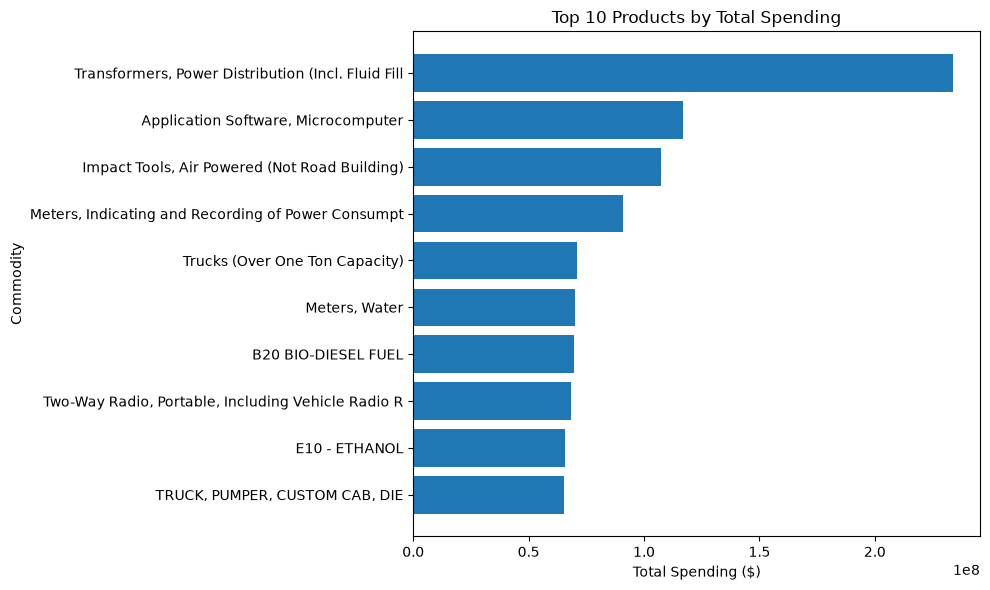

In [118]:
top_products = (
    df.groupby('COMMODITY_DESCRIPTION')['ITM_TOT_AM']
      .sum()
      .nlargest(10)
      .sort_values()
)


import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_products.index, top_products.values)

plt.xlabel('Total Spending ($)')
plt.ylabel('Commodity')
plt.title('Top 10 Products by Total Spending')
plt.tight_layout()
plt.show()

### Annual Spending Trend
Examine how total purchase spending changed over time.

In [ ]:
annual_spending = (
    df.groupby(df['AWARD_DATE'].dt.year)['ITM_TOT_AM']
      .sum()
)

plt.figure(figsize=(10, 5))
plt.plot(annual_spending.index, annual_spending.values, marker='o')

plt.xlabel('Year')
plt.ylabel('Total Spending ($)')
plt.title('Annual Purchase Spending Trend')
plt.xticks(annual_spending.index, rotation=45)
plt.tight_layout()
plt.show()

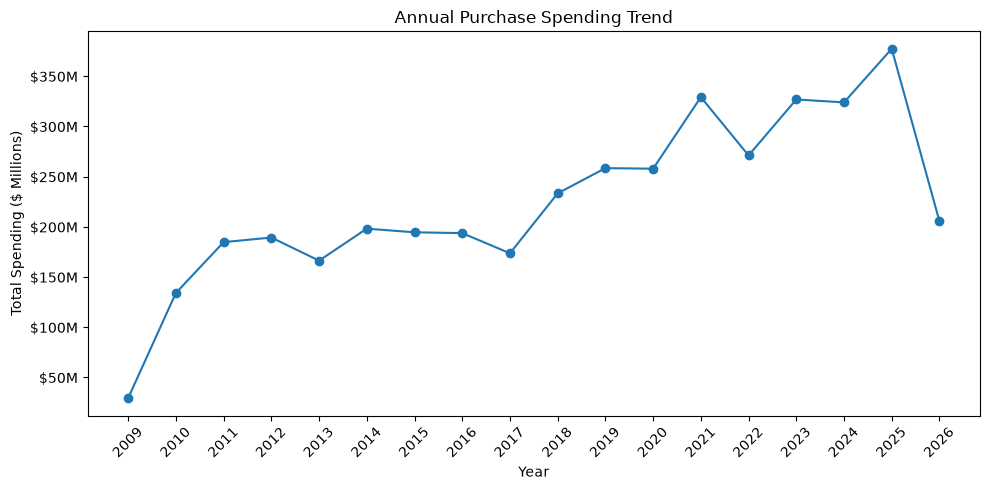

In [122]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 5))
plt.plot(annual_spending.index, annual_spending.values, marker='o')

plt.xlabel('Year')
plt.ylabel('Total Spending ($ Millions)')
plt.title('Annual Purchase Spending Trend')
plt.xticks(annual_spending.index, rotation=45)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1e6:.0f}M')
)

plt.tight_layout()
plt.show()

Annual Trend: Spending generally increased over time, reaching a peak of $377.3M in 2025; 2009 and 2026 represent partial years.

### Top 10 Vendor States by Total Spending
Compare total purchase spending across the leading vendor states.

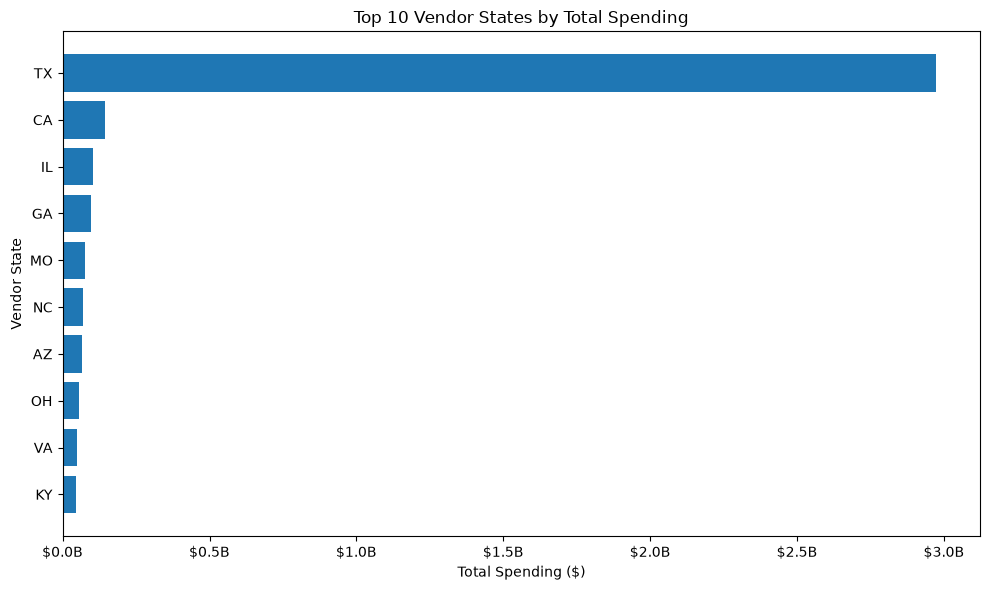

In [123]:
state_spending = (
    df.groupby('ST')['ITM_TOT_AM']
      .sum()
      .nlargest(10)
      .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(state_spending.index, state_spending.values)

plt.xlabel('Total Spending ($)')
plt.ylabel('Vendor State')
plt.title('Top 10 Vendor States by Total Spending')

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1e9:.1f}B')
)

plt.tight_layout()
plt.show()

Vendor Geography: Texas vendors dominated purchasing at approximately $2.97B, far exceeding spending with vendors in other states.

### Monthly Spending Pattern
Examine how total purchasing is distributed across months of the year.

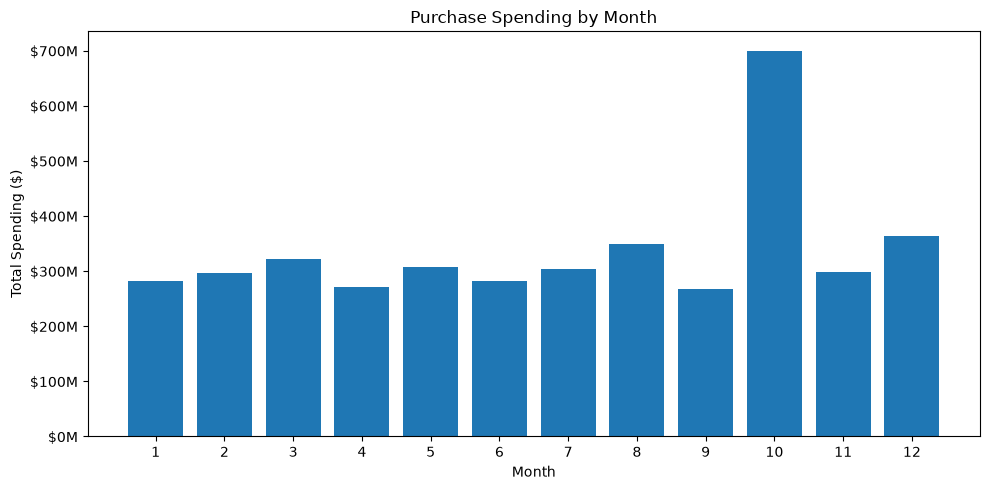

In [124]:
monthly_spending = (
    df.groupby(df['AWARD_DATE'].dt.month)['ITM_TOT_AM']
      .sum()
)

plt.figure(figsize=(10, 5))
plt.bar(monthly_spending.index, monthly_spending.values)

plt.xlabel('Month')
plt.ylabel('Total Spending ($)')
plt.title('Purchase Spending by Month')
plt.xticks(range(1, 13))

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1e6:.0f}M')
)

plt.tight_layout()
plt.show()

Monthly Spending: October recorded substantially higher aggregate spending than any other month, indicating a strong concentration of purchasing activity in that month.

### Top 10 Products by Purchase Frequency
Identify the commodity categories appearing most frequently in purchase records.

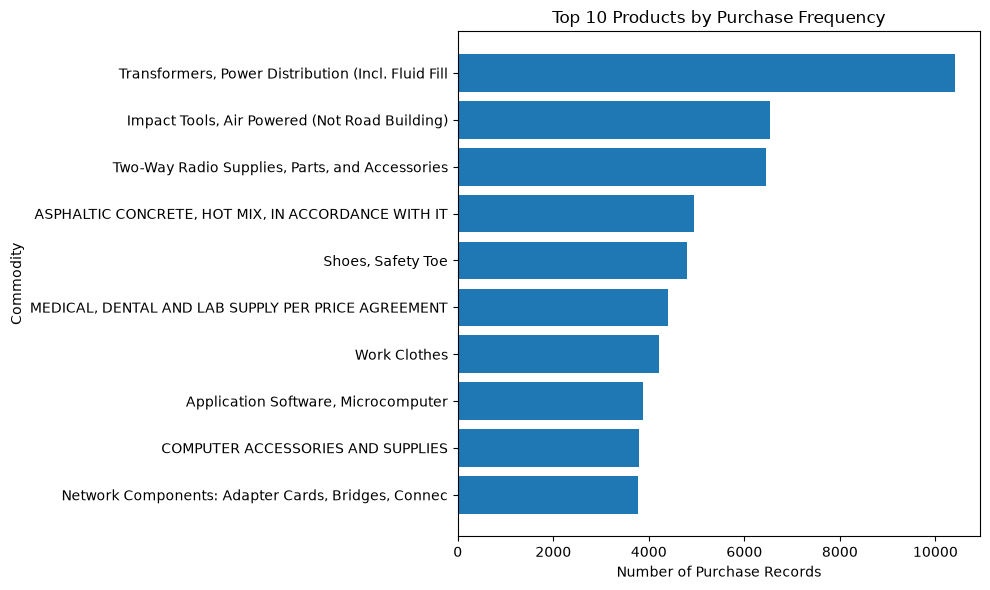

In [125]:
top_product_frequency = (
    df['COMMODITY_DESCRIPTION']
      .value_counts()
      .head(10)
      .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(top_product_frequency.index, top_product_frequency.values)

plt.xlabel('Number of Purchase Records')
plt.ylabel('Commodity')
plt.title('Top 10 Products by Purchase Frequency')

plt.tight_layout()
plt.show()

Purchase Frequency: Power distribution transformers were the most frequently recorded commodity, with 10,413 purchase records.

## Key Insights

- **Purchase orders are highly skewed:** The median purchase order was $2,010 and 75% were $7,200 or less, while the mean was $24,161 due to a small number of very large orders.

- **Vendor spending is highly concentrated:** The top 1% of vendors accounted for 58.8% of total spending, and the top 10% accounted for 93.2%.

- **Transformers are a major purchasing category:** Power distribution transformers ranked first in both total spending ($233.9M) and purchase-record frequency (10,413 records).

- **Spending increased over time:** Annual purchasing generally trended upward and reached its highest level in 2025 at approximately $377.3M. The 2009 and 2026 figures represent partial years.

- **Purchasing is geographically concentrated:** Texas-based vendors accounted for approximately $2.97B in spending, substantially more than vendors in any other state.

- **October stands out:** Aggregate October spending was substantially higher than other months, although further year-level analysis would be needed to determine whether this pattern is consistently seasonal.